In [7]:
# Manual k-fold cross validation(Visualization)
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [8]:
#Load Dataset
iris = load_iris()

X = iris.data
Y = iris.target

print("="*60)
print("Total Dataset Information")
print("="*60)
print("Total Samples:", len(X))
print("Total Features:", X.shape[1])
print("Total Classes:", len(np.unique(Y)))


Total Dataset Information
Total Samples: 150
Total Features: 4
Total Classes: 3


In [11]:
#K fold 
k = 5
kf = KFold( 
    n_splits = k,
    shuffle = True,
)

model = KNeighborsClassifier(n_neighbors=3)
accuracy_list = []
print("\n")
print("="*80)
print("K-FOLD CROSS VALIDATION")
print("="*80)

for fold,(train_index, test_index) in enumerate(kf.split(X),1):
    print("\n")
    print("-"*70)
    print("Fold",fold)
    print("-"*70)

    print("Training samples:", len(train_index))
    print("Testing samples:", len(test_index))

    print("\nTraining index")
    print(train_index)

    print("\nTesting index")
    print(test_index)

    X_train = X[train_index]
    X_test = X[test_index]

    Y_train = Y[train_index]
    Y_test = Y[test_index]

    model.fit(X_train,Y_train)

    prediction = model.predict(X_test)
    acc = accuracy_score(Y_test,prediction)
    accuracy_list.append(acc)
    print("\nAccuracy = %.2f%%"%(acc*100))

print("\n")
print("="*60)
print("Final Result")
print("="*60)

print("Accuracy of each fold")

for i,a in enumerate(accuracy_list):
    print("Fold",i+1,": %2f%%"%(a*100))

print("\nAverage Accuracy= %.2f%%"%(np.mean(accuracy_list)*100))





    

    



K-FOLD CROSS VALIDATION


----------------------------------------------------------------------
Fold 1
----------------------------------------------------------------------
Training samples: 120
Testing samples: 30

Training index
[  1   2   3   4   5   7   8   9  10  11  12  14  15  16  17  18  19  20
  21  22  23  24  25  26  27  28  29  30  31  32  33  34  36  37  39  40
  42  43  44  45  47  49  52  54  55  56  57  58  60  61  62  63  64  65
  66  67  69  70  71  72  73  74  76  77  78  79  81  83  86  87  88  89
  90  91  92  93  94  95  97  98  99 102 103 104 109 110 112 113 114 116
 117 118 119 120 121 123 124 125 126 127 128 129 130 131 132 134 135 137
 138 139 140 141 142 143 144 145 146 147 148 149]

Testing index
[  0   6  13  35  38  41  46  48  50  51  53  59  68  75  80  82  84  85
  96 100 101 105 106 107 108 111 115 122 133 136]

Accuracy = 93.33%


----------------------------------------------------------------------
Fold 2
----------------------------------------

   FOOTBALL WORLD CUP PREDICTION USING K-FOLD CV

[STEP 1] Loading Dataset...
  Total Matches : 48
  Columns       : ['Match_ID', 'Team1', 'Team2', 'Team1_FIFA_Rank', 'Team2_FIFA_Rank', 'Team1_Avg_Goals', 'Team2_Avg_Goals', 'Team1_Avg_Conceded', 'Team2_Avg_Conceded', 'Team1_Goals', 'Team2_Goals', 'Result']

  First 5 Rows:
    Team1        Team2  Team1_Goals  Team2_Goals    Result
   Brazil       Serbia            2            0 Team1_Win
   Brazil  Switzerland            1            0 Team1_Win
   Brazil     Cameroon            0            1 Team2_Win
Argentina Saudi Arabia            1            2 Team2_Win
Argentina       Mexico            2            0 Team1_Win

[STEP 2] Feature Engineering...
  3 new features added: Rank_Diff, Goal_Avg_Diff, Defense_Diff

[STEP 3] Defining Features and Target...
  Total Features : 9
  Target Classes : ['Team1_Win', 'Team2_Win', 'Draw']

  Result Distribution:
    Team1_Win       -> 28 matches
    Draw            -> 13 matches
    Team2_Win   

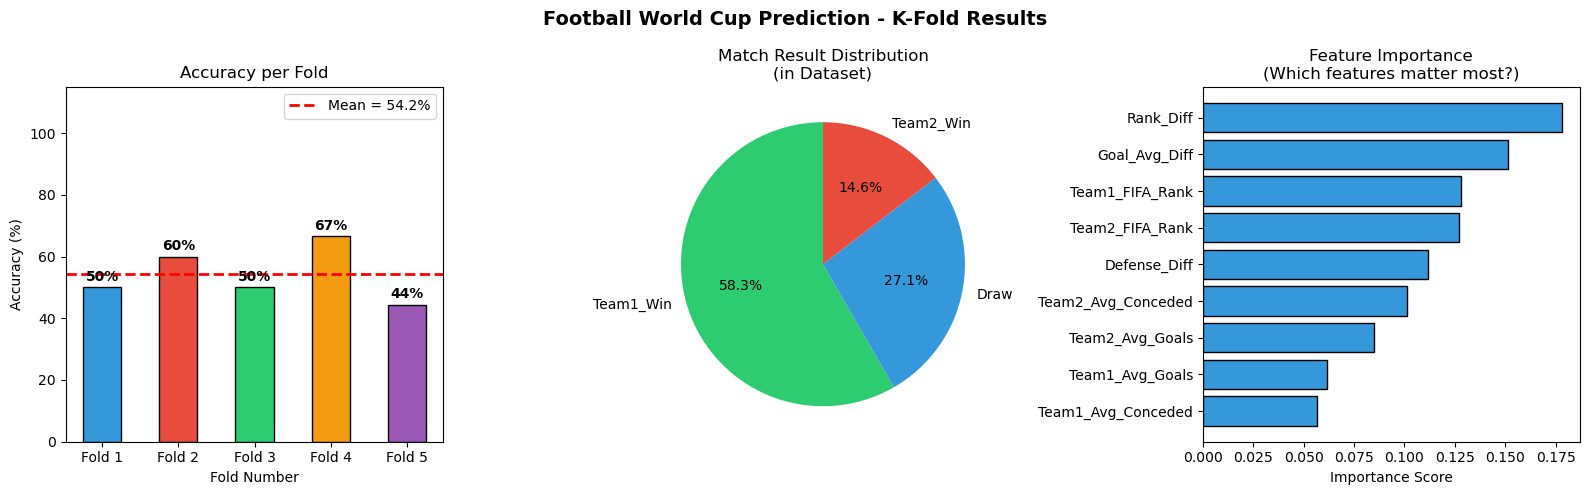

  Chart saved as 'worldcup_prediction_results.png'

   DONE! K-Fold Cross Validation Complete!


In [13]:
# ================================================================
#   FOOTBALL WORLD CUP RESULT PREDICTION USING K-FOLD CV
# ================================================================
#   What this code does:
#   1. Loads World Cup match data from a CSV file
#   2. Engineers extra features from the data
#   3. Trains a Random Forest model using K-Fold Cross Validation
#   4. Shows accuracy for each fold
#   5. Predicts results for new matches
#   6. Plots the results
# ================================================================

# ---- STEP 0: Import Libraries ----
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("   FOOTBALL WORLD CUP PREDICTION USING K-FOLD CV")
print("=" * 60)


# ================================================================
# STEP 1: LOAD THE DATASET
# ================================================================
print("\n[STEP 1] Loading Dataset...")

df = pd.read_csv('worldcup_data.csv')

print(f"  Total Matches : {len(df)}")
print(f"  Columns       : {list(df.columns)}")
print(f"\n  First 5 Rows:")
print(df[['Team1', 'Team2', 'Team1_Goals', 'Team2_Goals', 'Result']].head(5).to_string(index=False))


# ================================================================
# STEP 2: FEATURE ENGINEERING
#   We create 3 new features from existing ones to help the model
# ================================================================
print("\n[STEP 2] Feature Engineering...")

# Rank Difference: positive means Team1 is better ranked (lower rank = better)
df['Rank_Diff'] = df['Team2_FIFA_Rank'] - df['Team1_FIFA_Rank']

# Average Goals Difference: positive means Team1 scores more on average
df['Goal_Avg_Diff'] = df['Team1_Avg_Goals'] - df['Team2_Avg_Goals']

# Defense Difference: how much more Team2 concedes vs Team1
df['Defense_Diff'] = df['Team2_Avg_Conceded'] - df['Team1_Avg_Conceded']

print("  3 new features added: Rank_Diff, Goal_Avg_Diff, Defense_Diff")


# ================================================================
# STEP 3: DEFINE FEATURES (X) AND TARGET (y)
# ================================================================
print("\n[STEP 3] Defining Features and Target...")

feature_columns = [
    'Team1_FIFA_Rank',    # FIFA ranking of Team1 (lower = better)
    'Team2_FIFA_Rank',    # FIFA ranking of Team2
    'Team1_Avg_Goals',    # Average goals Team1 scores per match
    'Team2_Avg_Goals',    # Average goals Team2 scores per match
    'Team1_Avg_Conceded', # Average goals Team1 concedes per match
    'Team2_Avg_Conceded', # Average goals Team2 concedes per match
    'Rank_Diff',          # Derived: Team2_Rank - Team1_Rank
    'Goal_Avg_Diff',      # Derived: Team1_AvgGoals - Team2_AvgGoals
    'Defense_Diff'        # Derived: Team2_AvgConc - Team1_AvgConc
]

X = df[feature_columns]   # Input features
y = df['Result']          # Target: Team1_Win / Draw / Team2_Win

print(f"  Total Features : {len(feature_columns)}")
print(f"  Target Classes : {list(y.unique())}")
print(f"\n  Result Distribution:")
for label, count in y.value_counts().items():
    print(f"    {label:15} -> {count} matches")


# ================================================================
# STEP 4: K-FOLD CROSS VALIDATION
#   - Split data into K=5 equal parts (folds)
#   - Train on 4 parts, test on 1 part
#   - Repeat K times (each fold gets a turn as the test set)
# ================================================================
print("\n[STEP 4] Running K-Fold Cross Validation...")
print("-" * 60)

K = 5  # Number of folds

kf = KFold(n_splits=K, shuffle=True, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)

fold_accuracies = []

for fold_num, (train_idx, test_idx) in enumerate(kf.split(X), start=1):

    # --- Split data into training and testing sets ---
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    # --- Train the model ---
    model.fit(X_train, y_train)

    # --- Predict on test set ---
    y_pred = model.predict(X_test)

    # --- Calculate accuracy ---
    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)

    print(f"  Fold {fold_num} | Train: {len(X_train)} matches | "
          f"Test: {len(X_test)} matches | Accuracy: {acc:.2%}")

print("-" * 60)
print(f"  Mean Accuracy   : {np.mean(fold_accuracies):.2%}")
print(f"  Std Deviation   : {np.std(fold_accuracies):.2%}")
print(f"  Best Fold       : {max(fold_accuracies):.2%}")
print(f"  Worst Fold      : {min(fold_accuracies):.2%}")


# ================================================================
# STEP 5: TRAIN FINAL MODEL ON ALL DATA
#   After finding the best K-Fold accuracy, retrain on full data
# ================================================================
print("\n[STEP 5] Training Final Model on All Data...")

model.fit(X, y)
y_final_pred = model.predict(X)

print("\n  Classification Report:")
print(classification_report(y, y_final_pred))


# ================================================================
# STEP 6: PREDICT NEW MATCHES
# ================================================================
print("[STEP 6] Predicting New Match Results...")
print("-" * 60)

# New match data (you can change these values!)
new_matches_data = {
    'Team1_FIFA_Rank':    [2,   1,   5  ],
    'Team2_FIFA_Rank':    [9,   3,   4  ],
    'Team1_Avg_Goals':    [2.1, 2.3, 2.0],
    'Team2_Avg_Goals':    [1.7, 1.9, 1.8],
    'Team1_Avg_Conceded': [0.6, 0.7, 0.6],
    'Team2_Avg_Conceded': [0.9, 0.8, 0.8],
    'Rank_Diff':          [7,   2,  -1  ],
    'Goal_Avg_Diff':      [0.4, 0.4, 0.2],
    'Defense_Diff':       [0.3, 0.1, 0.2]
}
match_names = ['Argentina vs Germany', 'Brazil vs France', 'Spain vs England']

new_df = pd.DataFrame(new_matches_data)
predictions   = model.predict(new_df[feature_columns])
probabilities = model.predict_proba(new_df[feature_columns])

for i, name in enumerate(match_names):
    print(f"\n  Match: {name}")
    print(f"  Predicted Result: {predictions[i]}")
    print(f"  Win Probabilities:")
    for j, cls in enumerate(model.classes_):
        prob = probabilities[i][j]
        bar  = "#" * int(prob * 30)
        print(f"    {cls:15} {prob:5.1%}  [{bar}]")


# ================================================================
# STEP 7: VISUALIZATION - 3 CHARTS
# ================================================================
print("\n[STEP 7] Generating Charts...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Football World Cup Prediction - K-Fold Results', fontsize=14, fontweight='bold')

# --- Chart 1: Accuracy per Fold (Bar Chart) ---
fold_labels = [f'Fold {i+1}' for i in range(K)]
bar_colors  = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
bars = axes[0].bar(fold_labels, [a * 100 for a in fold_accuracies],
                   color=bar_colors, edgecolor='black', width=0.5)

axes[0].axhline(y=np.mean(fold_accuracies) * 100, color='red',
                linestyle='--', linewidth=2,
                label=f'Mean = {np.mean(fold_accuracies):.1%}')

# Add value labels on bars
for bar, acc in zip(bars, fold_accuracies):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1,
                 f'{acc:.0%}', ha='center', va='bottom', fontweight='bold')

axes[0].set_title('Accuracy per Fold', fontsize=12)
axes[0].set_xlabel('Fold Number')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 115)
axes[0].legend()

# --- Chart 2: Result Distribution (Pie Chart) ---
result_counts = y.value_counts()
pie_colors    = ['#2ecc71', '#3498db', '#e74c3c']
axes[1].pie(result_counts.values,
            labels=result_counts.index,
            colors=pie_colors,
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 10})
axes[1].set_title('Match Result Distribution\n(in Dataset)', fontsize=12)

# --- Chart 3: Feature Importance (Horizontal Bar) ---
feat_importance = pd.Series(model.feature_importances_, index=feature_columns).sort_values()
axes[2].barh(feat_importance.index, feat_importance.values,
             color='#3498db', edgecolor='black')
axes[2].set_title('Feature Importance\n(Which features matter most?)', fontsize=12)
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('worldcup_prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("  Chart saved as 'worldcup_prediction_results.png'")
print("\n" + "=" * 60)
print("   DONE! K-Fold Cross Validation Complete!")
print("=" * 60)